# Homework 3

**Dataset**  

The dataset used is the 1996 Census Income dataset from UCI Machine Learning Repository. It contains 48,842 instances and 14 features. The problem it addresses is the binary classification problem of predicting annual income > 50k or <= 50k given the 14 characteristics. Link to dataset: https://archive.ics.uci.edu/dataset/20/census+income

###Part 1

In [10]:
## NeuralNetwork Class

import numpy as np
import pandas as pd

class NeuralNetwork:
  """
  A 2-layer neural network built from scrach with numpy.
  Architecture:
    Input X --> Hidden Layer (ReLU) --> Output Layer (Sigmoid) --> prediction

    X --> Z1, A1 --> Z2, A2 --> Prediction
      W1         W2
  """
  def __init__(self, input_size, hidden_size=32, learning_rate=0.01, seed=42):
    """
    Initialization method:
      - input_size: # of columns/features in X
      - hidden_size: # of neurons in hidden layer
      - learning_rate: step size for gradient descent
      - seed: random seed for reproducibility
    """
    np.random.seed(seed)
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.learning_rate = learning_rate

    # random initialization (we use small values so activations don't immediately explode)
    # W1 maps input --> hidden, b1 is hidden bias
    self.W1 = 0.01 * np.random.randn(self.input_size, self.hidden_size)
    self.b1 = np.zeros((1, self.hidden_size))
    # W2 maps hidden --> output, b2 is output bias
    self.W2 = 0.01 * np.random.rand(self.hidden_size, 1)
    self.b2 = np.zeros((1, 1))
    # store intermediate values during forward pass for backprop
    self.cache = {}

  ## Activation functions
  def sigmoid(self, z):
    # Sigmoid turns any real-valued number into a probability between 0 and 1
    return 1 / (1 + np.exp(-z))

  def relu(self, z):
    # ReLU keeps positive values and maps negative values to 0
    return np.maximum(0, z)

  def relu_derivative(self, z):
    # slope of ReLU (f(x) = max(0,x)) is 1 where x > 0, 0 everywhere else
    return np.where(z > 0, 1, 0)

  ## Forward propogation
  def forward_prop(self, X):
    """
    X shape: (batch_size, input_size)
    Steps:
    1. summation into hidden layer: Z1 = XW1 + b1
    2. activation at hidden layer: A1 = ReLU(Z1)
    3. summation into output layer: Z2 = A1W2 + b2
    4. activation at output: A2 = sigmoid(Z2) = predicted probability
    """
    Z1 = X.dot(self.W1) + self.b1
    A1 = self.relu(Z1)
    Z2 = A1.dot(self.W2) + self.b2
    A2 = self.sigmoid(Z2)

    # save what we need for backprop
    self.cache["X"] = X
    self.cache["Z1"] = Z1
    self.cache["A1"] = A1
    self.cache["Z2"] = Z2
    self.cache["A2"] = A2
    return A2 # probabilities, shape (batch_size, 1)

  ## Cost/loss
  def cost(self, y_true, y_pred):
    """
    Cost method: binary cross-entropy loss
    y_true shape: (batch_size, 1), values are either 0 or 1
    from now on we will refer to batch_size as m for brevity and encoding
    y_pred shape: (m, 1), predicted probabilities from 0 to 1
    loss will punish wrong predictions heavily
    """
    m = y_true.shape[0]
    # prevent taking log(0) by adding a tiny eps value
    eps = 1e-12
    loss = -(1 / m) * np.sum(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))
    return loss

  ## Backward propogation
  def backprop(self, y_true):
    """
    Backprop method: how much each weight contributes to the prediction error
    1. calculate gradients at the output layer
    2. propogate those gradients backward through each prev layer until we reach input layer
    - start at output layer derivatives. Figure out how much each weight and bias that go into the output affected the error
    - compute partial derivatives . Move one layer back and find how much ws and bs affected error in that layer
    - go back a layer and repeat until reach input layer

    Function computes gradients for W1, b1, W2, and b2
    """
    X = self.cache["X"] # input data
    Z1 = self.cache["Z1"] # weighted sum entering the hidden layer before activation
    A1 = self.cache["A1"] # hidden layer output after activation
    A2 = self.cache["A2"] # output probabilities
    m = y_true.shape[0]
    # derivative: dZ2 = (A2 - y_true)
    dZ2 = (A2 - y_true) # shape (m,1)
    # gradients for output layer parameters
    dW2 = (1/m) * A1.T.dot(dZ2) # shape (hidden_size,1)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True) # shape (1,1)
    # now backprop into hidden layer:
    # dA1 = dZ2 * W2^T
    dA1 = dZ2.dot(self.W2.T) # shape (m, hidden_size)
    # dZ1 = dA1 * ReLU'(Z1)
    dZ1 = dA1 * self.relu_derivative(Z1) # shape (m, hidden_size)
    # Gradients for hidden layer parameters
    dW1 = (1/m) * X.T.dot(dZ1) # shape (input_size, hidden_size)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True) # shape (1, hidden_size)
    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

  ## Training (gradient descent)
  def train(self, X_train, y_train, epochs=50, batch_size=256, verbose=True):
    """
    Gradient descent loop for training
    use mini-batch gradient descent because fastest in between full batch and stochastic
    """
    m = X_train.shape[0]
    losses = []

    for epoch in range(1, epochs+1):
      # shuffle the data each epoch so batches are different each time
      indices = np.random.permutation(m)
      X_shuffled = X_train[indices]
      y_shuffled = y_train[indices]

      # loop over mini-batches
      for start in range(0, m, batch_size):
        end = start + batch_size
        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        # 1. forward pass
        y_pred = self.forward_prop(X_batch)
        # 2. backward pass (compute gradients)
        grads = self.backprop(y_batch)
        # 3. gradient descent update (move weights opposite the gradient)
        self.W1 -= self.learning_rate * grads["dW1"]
        self.b1 -= self.learning_rate * grads["db1"]
        self.W2 -= self.learning_rate * grads["dW2"]
        self.b2 -= self.learning_rate * grads["db2"]
      # track loss once per epoch (on full training set)
      train_pred = self.forward_prop(X_train)
      epoch_loss = self.cost(y_train, train_pred)
      losses.append(epoch_loss)

      # print first and every fifth epoch
      if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {epoch_loss:.4f}")
    return losses

  ## Prediction
  def predict(self, X, threshold=0.5):
    """
    predict method
    returns
    - probs: predicted probabilities (m,1)
    - preds: predicted class labels (0 or 1) using a threshold
    """
    probs = self.forward_prop(X)
    preds = (probs >= threshold).astype(int)
    return probs, preds

In [11]:
## Test class on dataset
"""
we must process dataset so it's suitable for our neural network
currently has numeric, categorical, and a label column, so must
- one-hot encode categorical columns
- standardize numeric columns so they're on similar scale
- split into X and y (train/test)
- train with mini-batches because one-hot makes the dataset significantly larger
"""

def preprocess_data(filename):
  """
  loads and processes data and returns X_train, y_train, X_test, y_test arrays
  """
  # dataset columns
  col_names = [
      "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
      "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
      "hours-per-week", "native-country", "income"
  ]
  # read file
  df = pd.read_csv(filename, names=col_names, na_values="?", skipinitialspace=True)
  # remove rows with missing values
  df = df.dropna()
  # convert label to binary
  df["income"] = df["income"].str.strip()
  # >50k --> 1, <=50k --> 0
  y = (df["income"] == ">50K").astype(int).values.reshape(-1, 1)
  # split features (X) and label
  X_df = df.drop(columns=["income"])
  # separate numeric and categorical columns
  numeric_cols = X_df.select_dtypes(include=[np.number]).columns
  categorical_cols = X_df.select_dtypes(exclude=[np.number]).columns
  # one-hot encode categorical columns
  X_cat = pd.get_dummies(X_df[categorical_cols], drop_first=True)
  # standardize numeric columns so numeric inputs are similar scale
  X_num = (X_df[numeric_cols] - X_df[numeric_cols].mean()) / (X_df[numeric_cols].std() + 1e-12)
  # combine numeric + one-hot into one big numeric table
  X_all = pd.concat([X_num, X_cat], axis=1)
  # convert to numpy float aray
  X = X_all.values.astype(float)
  # train/test split
  np.random.seed(42)
  indices = np.random.permutation(len(X))
  split = int(0.8*len(X))
  train_indices = indices[:split]
  test_indices = indices[split:]
  X_train = X[train_indices]
  y_train = y[train_indices]
  X_test = X[test_indices]
  y_test = y[test_indices]

  return X_train, X_test, y_train, y_test

def accuracy(y_true, y_pred_labels):
  # percent correct
  return np.mean(y_true.flatten() == y_pred_labels.flatten())

## Test:
filename = "adult.data"
X_train, X_test, y_train, y_test = preprocess_data(filename)
# using a subset to decrease training time
subset_n = 20000 # roughly half, enough data while still preserving efficiency
X_train_sub = X_train[:subset_n]
y_train_sub = y_train[:subset_n]

# create and train neural network
nn = NeuralNetwork(
    input_size=X_train_sub.shape[1],
    hidden_size = 32, # 32 neurons: enough capacity for the model to learn meaningful patterns without making network too large
    learning_rate=0.05, # allows model to converge quickly while still being stable
    seed=42
)

losses = nn.train(
    X_train_sub,
    y_train_sub,
    epochs=30, # sufficient for loss to converge and stabalize
    batch_size = 256, # mini-batch gradient descent, balance between computational efficiency and stable learning
    verbose=True
)

# evaluate on test set
probs, preds = nn.predict(X_test, threshold = 0.5) # neural network output probs are between 0 and 1, so 0.5 is a natural cutoff
test_acc = accuracy(y_test, preds)
print("Test Accuracy:", test_acc)


Epoch 1/30, Loss: 0.5808
Epoch 5/30, Loss: 0.4041
Epoch 10/30, Loss: 0.3387
Epoch 15/30, Loss: 0.3271
Epoch 20/30, Loss: 0.3221
Epoch 25/30, Loss: 0.3195
Epoch 30/30, Loss: 0.3174
Test Accuracy: 0.8471738770097795


**Explain which technique you used and why**  

Two techniques I employ are using a subset of the data and using mini-batch gradient descent. This is because the Census Income dataset becomes especialy large and computationally expensive to train on after preprocessing, as one-hot encoding of the categorical variables significantly increases the number of input features. To balance this, I trained the model using a subset of 20,000 training examples instead of the full dataset. This subset was large enough to preserve the overall structure and patterns of the data while greatly reducing computational load.  
  
  Mini-batch gradient descent is also used with a batch size of 256. Instead of computing gradients using the entire dataset at once, as in full-batch gradient descent, mini-batch gradient descent updates the model parameters using smaller portions of the data at a time. This reduces the amount of computation required per update and improves training speed.  
  

  Using both the 20,000 example subset and mini-batch gradient descent allowed the neural network to train extremely quickly while still still achieving strong performance, with the loss steadily decreasing and the final test accuracy reaching approximately 84.7%. This demonstrates that the model was able to learn effectively while maintaining efficient runtime.

###Part 2  
The chosen framework is PyTorch.

**Task 1**  
In order to implement a 2-layer neural network (NN) in PyTorch, I needed to find resources that explained how to define a neural network, how forward propogation is written, and how automatic backward propogation is handled, as well as which PyTorch tools are used for training loops. I used the following resources:
- https://docs.pytorch.org/tutorials/recipes/recipes/defining_a_neural_network.html
- https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
- https://alan-turing-institute.github.io/Intro-to-transparent-ML-course/10-deep-cnn-rnn/multilayer-nn.html

**First resource: Defining a Neural Network**
This resource demonstrated the standard Pytorch pattern for creating a neural network through subclassing the torch.nn.Module class, defining layers in __init__, and implementing the forward() function. This structure allows PyTorch to automatically track all tensor operations during forward propogation. It also introduced key components needed to represent neural netowrk computations, including:
- torch.nn.Module, which serves as the base class for defining neural networks
- torch.nn.Linear, which creates fully-connected layers by performing weighted sums and bias addition
- and the forward() method, which defines how input data flows through the network during forward propogation
This was key for understanding how to organize the network structure so that PyTorch can correctly track computations and prepare them for automatic gradient calculation during backpropogation.
  
  **Second resource: Build the Neural Network**
  This resource explains how defining a model connects to the training process. It details how tensors flow through the layers during forward propogation, including how input features are transformed into outputs through matrix multiplication and activation functions. It also explains the importance of tensor shape conventions, including the batch dimension and feature dimension, which are necessary for correctly performing matrix operations. Additionally, this resource introduced important PyTorch tools used during training, including:
  - loss functions to measure prediction error
  - optimizers to update model parameters
  - the training loop structure, which repeatedly performs forward propogation, computes loss, performs backward propogation, and updates weights

  **Third resource: Alan Turing Institute- Multilayer Neural Networks and Computational Graphs**
  This resource provides important theoretical and practical explanations of how multilayer neural networks operate and how PyTorch represents neural network computations using computational graphs. It explains how each layer performs weighted sums followed by activation functions, allowing the network to learn nonlinear relationships between input features and output predictions.

   Additionally, this resource explains how PyTorch constructs a computational graph dynamically during forward propogation. This graph records all operations performed on tensors, which allows Pytorch to automatically compute gradients during backward propogation. When tensors have requires_grad=True, PyTorch tracks all operations performed on them, and calling .backward() computes gradiants for all parameters in the network automatically. These gradients are then used to update the weights during gradient descent.

   This resource was necessary to understand how PyTorch manages forward propogation, backward propogation, and gradient computation internally, which saves users from having to manually implement derivatives such as in Part 1. It also helps to understand the role of tensors, computational graphs, and automatic differentiation in effeciently training neural networks using PyTorch.

**Task 2**

In [12]:
## imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

Dataset shape (rows, columns): (32561, 15)

First 5 rows:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-

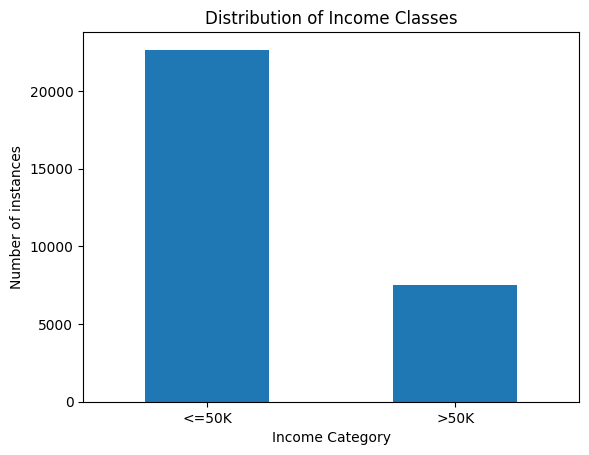


Percent distribution of income classes:
income
<=50K    75.107751
>50K     24.892249
Name: count, dtype: float64

Numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


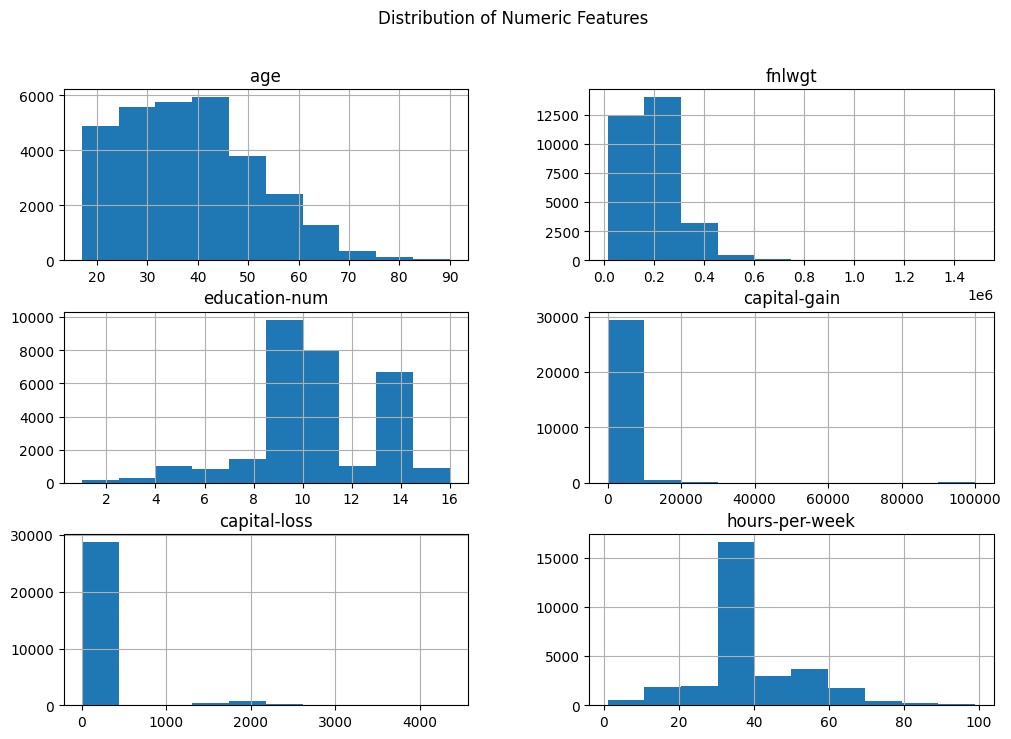


Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']

Value counts for workclass:
workclass
Private             22286
Self-emp-not-inc     2499
Local-gov            2067
State-gov            1279
Self-emp-inc         1074
Federal-gov           943
Without-pay            14
Name: count, dtype: int64

Value counts for education:
education
HS-grad         9840
Some-college    6678
Bachelors       5044
Masters         1627
Assoc-voc       1307
11th            1048
Assoc-acdm      1008
10th             820
7th-8th          557
Prof-school      542
Name: count, dtype: int64

Value counts for marital-status:
marital-status
Married-civ-spouse       14065
Never-married             9726
Divorced                  4214
Separated                  939
Widowed                    827
Married-spouse-absent      370
Married-AF-spouse           21
Name: count, dtype: int64

Value counts for occupation:
occupation
Prof-

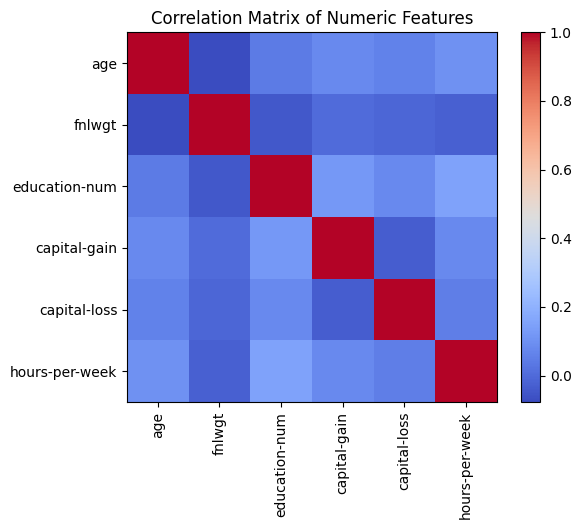

In [13]:
## 1. EDA

# dataset has no header row so we manually name columns
col_names = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]

df = pd.read_csv("adult.data", names=col_names, skipinitialspace=True)

# print basic information about the dataset
print("Dataset shape (rows, columns):", df.shape)

# print first few rows to visually inspect structure
print("\nFirst 5 rows:")
print(df.head())

# print data types of columns
print("\nData types of columns:")
print(df.dtypes)

# show summary statistics for numeric columns
print("\nSummary statistics for numeric columns:")
print(df.describe())

# show missing value count
print("\nMissing (?) values:")
print((df == "?").sum())

# replace "?"s with actual NaN values; missing vals are stored as ? in this dataset
df = df.replace("?", np.nan)

# count missing vals again to confirm equal
print("\nMissing values after replacement:")
print(df.isna().sum())

# drop rows with missing values
df = df.dropna()

# get updated shape
print("\nDataset shape after dropping missing values (rows, columns):", df.shape)

# target variable analysis

# count number of examples in each income class
income_counts = df["income"].value_counts()
print("\nIncome class distribution:")
print(income_counts)

# plot distribution
plt.figure()
income_counts.plot(kind="bar")
plt.title("Distribution of Income Classes")
plt.xlabel("Income Category")
plt.ylabel("Number of instances")
plt.xticks(rotation=0)
plt.show()

# compute percentage distribution
income_percent = income_counts / len(df) * 100
print("\nPercent distribution of income classes:")
print(income_percent)

# investigate numeric feature distributions to identify scale and skew issues
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns:", numeric_cols)
# plot histograms for numeric features only
df[numeric_cols].hist(figsize=(12,8))
plt.suptitle("Distribution of Numeric Features")
plt.show()

# categorical feature distributions
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("\nCategorical columns:", categorical_cols)
# show frequency counts for each categorical feature
for col in categorical_cols:
  print(f"\nValue counts for {col}:")
  print(df[col].value_counts().head(10))

# feature correlation analysis
# compute correlation matrix
corr_matrix = df[numeric_cols].corr()
print("correlation matrix:", df[numeric_cols].corr())
# plot correlation heatmap
plt.figure()
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.title("Correlation Matrix of Numeric Features")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.show()

**EDA Analysis**  
The Census Income dataset initially contained 32,561 rows and 15 columns, consisting of a mix of numeric and categorical features, as well as the target variable (income). After replacing missing values (represented as “?”) with NaN and removing incomplete rows, the dataset size was reduced to 30,162 rows, meaning approximately 7.4% of the data contained missing values, primarily in the workclass, occupation, and native-country columns. Since neural networks cannot handle missing values directly, dropping these rows ensured that the training data was clean and suitable for modeling.
<br>
**Target variable distribution and class imbalance**  
The income distribution shows a clear class imbalance:
≤50K: 22,654 instances (75.1%) | >50K: 7,508 instances (24.9%)

This imbalance indicates that most individuals in the dataset fall into the lower income category. This is important because a model could achieve high accuracy by simply predicting the majority class, so it is necessary to ensure the model learns meaningful patterns rather than relying on this imbalance. This also justifies using metrics like loss and validation accuracy during training to verify genuine learning.
<br>
Several important patterns emerged from the numeric features:

- Age follows a roughly bell-shaped distribution centered around the late 30s, with fewer individuals at very young and very old ages.
- Hours-per-week is heavily concentrated around 40 hours, indicating that full-time work is most common.
Education-num shows clustering around values corresponding to high school and college education levels.
- Capital-gain and capital-loss are highly skewed, with most values equal to zero and a small number of very large outliers. This indicates that capital income is rare but potentially very influential.
fnlwgt has extremely large magnitude values, ranging up to over 1.4 million.

These large differences in feature scale confirm the importance of normalization, since neural networks are sensitive to feature magnitude and large-scale features can dominate gradient updates if not normalized.

**Key categorical observations:**
The majority of individuals work in the Private sector, making up over 70% of entries.
Most individuals have HS-grad or Some-college education, while advanced degrees are less common.
The largest marital group is Married-civ-spouse, followed by Never-married.
The majority race is White, and the majority native country is the United States, representing over 90% of entries.
The dataset also contains a gender imbalance, with significantly more males than females.
These categorical variables are important predictive features and required one-hot encoding before being used in the neural network.


The correlation matrix shows that most numeric features have weak correlations with one another, suggesting that each feature provides largely independent information. The strongest observed relationship is between education-num and hours-per-week (r=0.153), indicating a weak positive association between education level and work hours. The negative corrleation between fnlwgt and age displayed on the heatmap with r = -0.077 are very weak and indicate minimal linear relationship rather than strong inverse dependence. Overall, the low correlations between features are beneficial because they reduce colinearity and allow the neural network to learn meaningful patterns from diverse inputs.

In [14]:
## 2. Train-Dev-Test-Split
"""
Using:
- train = 80% for learning weights
- dev/validation = 10% for tuning hyperparams
- test = 10% for final evaluation
"""

# convert label to binary y: >50k --> 1, <=50k --> 0
y = (df["income"] == ">50K").astype(int).values.reshape(-1,1) # convert to column of shape (5,1)

# separate features
X_df = df.drop(columns=["income"])
# identify numeric vs categorical columns
numeric_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_df.columns if c not in numeric_cols]
print("\nNumeric columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)
# one-hot encode categorical features
X_cat = pd.get_dummies(X_df[categorical_cols], drop_first=True)
# take a copy of the numeric features, not normalizing them yet
X_num = X_df[numeric_cols].copy()
# combine into one full numeric matrix
X_all = pd.concat([X_num, X_cat], axis=1)
X = X_all.values.astype(np.float32)
y = y.astype(np.float32)

# shuffle and split
np.random.seed(42)
m = X.shape[0]
indices = np.random.permutation(m)

train_end = int(0.8 * m)
dev_end = int(0.9 * m)

train_indices = indices[:train_end]
dev_indices = indices[train_end:dev_end]
test_indices = indices[dev_end:]

X_train, y_train = X[train_indices], y[train_indices]
X_dev, y_dev = X[dev_indices], y[dev_indices]
X_test, y_test = X[test_indices], y[test_indices]

print("\nSplit sizes:")
print("Train:", X_train.shape, y_train.shape)
print("Dev:", X_dev.shape, y_dev.shape)
print("Test:", X_test.shape, y_test.shape)


Numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Split sizes:
Train: (24129, 96) (24129, 1)
Dev: (3016, 96) (3016, 1)
Test: (3017, 96) (3017, 1)


In [15]:
## 3. Forward propogation
"""
2-layer network design:
- layer 1: linear(input_size --> hidden_size)
- activation: ReLU
- Layer 2: Linear(hidden_size --> 1)
- output: logit (raw score)

we will use BCEWithLogitsLoss as it combines sigmoid activation and binary cross-entropy loss
"""

class TwoLayerNN(nn.Module):
  """
  A 2-layer neural network for binary classification
  Layer layout:
    X --> Lienar --> ReLU --> Linear --> output logits
  We use BCEWithLogitsLoss which expects logits (raw scores)
  """
  def __init__(self, input_size, hidden_size=32):
    super().__init__()
    self.fc1 = nn.Linear(input_size, hidden_size) # first layer
    self.relu = nn.ReLU() # activation function
    self.fc2 = nn.Linear(hidden_size, 1) # output layer

  # forwardprop
  def forward(self, x):
    z1 = self.fc1(x) # weighted sum + bias into hidden layer
    a1 = self.relu(z1) # ReLU activation
    logits = self.fc2(a1)
    return logits

"""
hyperparamters I will use:
- hidden_size = 32
- learning_rate = 0.001
- optimizer: Adam
- batch_size = 256
- epochs = 10-20
"""

' \nhyperparamters I will use:\n- hidden_size = 32\n- learning_rate = 0.001\n- optimizer: Adam\n- batch_size = 256\n- epochs = 10-20\n'

In [16]:
"""
4. Final cost function:
criterion = nn.BCEWithLogitsLoss()
- expecgts model outputs as logits shape (batch, 1)
- labels 0/1, shape (batch, 1)
"""

'\n4. Final cost function:\ncriterion = nn.BCEWithLogitsLoss()\n- expecgts model outputs as logits shape (batch, 1)\n- labels 0/1, shape (batch, 1)\n'

In [17]:
## 5. Gradient descent training (Adam) + regularization + normalization experiment
"""
2 experiments will be run:
  1. without normalizing numeric columns
  2. with normalizing numeric columns
"""

# helper to normalize numeric columns
def normalize_numeric(X_train, X_dev, X_test, numeric_feature_count):
  """
  normalizes only the first 'numeric_feature_count' columns
  reminder: X is structured as [numeric columns | one-hot columns]
  compute mean/std from train, then apply to dev/test
  """
  X_train2 = X_train.copy()
  X_dev2 = X_dev.copy()
  X_test2 = X_test.copy()

  train_num = X_train2[:, :numeric_feature_count]
  mean = train_num.mean(axis=0)
  std = train_num.std(axis=0) + 1e-12

  X_train2[:, :numeric_feature_count] = (X_train2[:, :numeric_feature_count] - mean)/std
  X_dev2[:, :numeric_feature_count] = (X_dev2[:, :numeric_feature_count] - mean) / std
  X_test2[:, :numeric_feature_count] = (X_test2[:, :numeric_feature_count] - mean) / std

  return X_train2, X_dev2, X_test2

# training and evaluation helpers
def make_dataloaders(X_train, y_train, X_dev, y_dev, batch_size=256):
  # wraps NumPy arrays into PyTorch dataloarders, which handle mini-batching and shuffling
  train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
  dev_dataset = TensorDataset(torch.tensor(X_dev), torch.tensor(y_dev))
  train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  dev_dataloader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)
  return train_dataloader, dev_dataloader

def accuracy_from_logits(logits, y_true):
  # convert logits --> probabilities --> predicted labels, then compute accuracy
  probs = torch.sigmoid(logits) # convert raw scores into probabilities
  preds = (probs >= 0.5).float() # threshold at 0.5
  acc = (preds.eq(y_true)).float().mean() # percent correct
  return acc.item()

def train_model(
    X_train, y_train, X_dev, y_dev,
    input_size, hidden_size=32, learning_rate=0.001,
    epochs=15, batch_size=256, weight_decay=1e-4):
  """
  trains a twolayernn using adam optimizer
  weight_decay is a simple regularization method (L2 regularization).
  It prevents the model from making weights too large so it can generalize better
  """
  # create model
  model = TwoLayerNN(input_size=input_size, hidden_size=hidden_size)
  # loss function (final cost)
  criterion = nn.BCEWithLogitsLoss()
  # optimizer (gradient descent variant). Adam trains faster and often better than reg SGD
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  # DataLoaders for mini-batch training
  train_dataloader, dev_dataloader = make_dataloaders(X_train, y_train, X_dev, y_dev, batch_size=batch_size)
  train_losses=[]
  dev_losses=[]
  dev_accs=[]

  for epoch in range(1, epochs+1):
    model.train() # initiates PyTorch training
    running_loss = 0.0
    for X_batch, y_batch in train_dataloader:
      # forwardprop
      logits = model(X_batch)
      # compute loss (cost)
      loss = criterion(logits, y_batch)
      # backprop (PyTorch autograd computes gradients)
      optimizer.zero_grad() # clear old grads from previous step
      loss.backward() # compute new gradients
      optimizer.step() # update weights using Adam
      running_loss += loss.item()
    avg_train_loss = running_loss/len(train_dataloader)
    train_losses.append(avg_train_loss)

    # evaluate on dev set each epoch
    model.eval() # initiates PyTorch evaluating
    with torch.no_grad(): # no gradient tracking needed for evaluation
      dev_running_loss = 0.0
      dev_running_acc = 0.0

      for X_batch, y_batch in dev_dataloader:
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        dev_running_loss += loss.item()
        dev_running_acc += accuracy_from_logits(logits, y_batch)

      avg_dev_loss = dev_running_loss / len(dev_dataloader)
      avg_dev_acc = dev_running_acc / len(dev_dataloader)

      dev_losses.append(avg_dev_loss)
      dev_accs.append(avg_dev_acc)

    if epoch == 1 or epoch % 5 == 0:
      print(f"Epoch {epoch}/{epochs}")
      print(f"Train Loss: {avg_train_loss:.4f}")
      print(f"Dev Loss: {avg_dev_loss:.4f}")
      print(f"Dev Acc: {avg_dev_acc:.4f}")

  return model, train_losses, dev_losses, dev_accs

## Experiment 1: no normalization
input_size = X_train.shape[1]
numeric_feature_count = len(numeric_cols)
print("\n**Experiment 1: No Normalization")
model_1, train_losses_1, dev_losses_1, dev_accs_1 = train_model(
    X_train, y_train, X_dev, y_dev,
    input_size = input_size,
    hidden_size = 32,
    learning_rate = 0.001,
    epochs = 15,
    batch_size = 256,
    weight_decay = 1e-4
)

## Experiment 2: with normalization
print("\n**Experiment 2: With Normalization")
X_train_norm, X_dev_norm, X_test_norm = normalize_numeric(X_train, X_dev, X_test, numeric_feature_count=numeric_feature_count)

model_2, train_losses_2, dev_losses_2, dev_accs_2 = train_model(
    X_train_norm, y_train, X_dev_norm, y_dev,
    input_size=input_size,
    hidden_size=32,
    learning_rate=0.001,
    epochs=15,
    batch_size=256,
    weight_decay=1e-4
)

## Results on the test set
def evaluate_on_test(model, X_test, y_test):
  # evaluates accuracy on the test set
  model.eval()
  X_test_t = torch.tensor(X_test)
  y_test_t = torch.tensor(y_test)
  with torch.no_grad():
    logits = model(X_test_t)
    test_acc = accuracy_from_logits(logits, y_test_t)
  return test_acc

test_acc_1 = evaluate_on_test(model_1, X_test, y_test)
test_acc_2 = evaluate_on_test(model_2, X_test_norm, y_test)
print("\nFinal test accuracy (without normalization):", test_acc_1)
print("Final test accuracy (with normalization):", test_acc_2)



**Experiment 1: No Normalization
Epoch 1/15
Train Loss: 48.7855
Dev Loss: 53.5701
Dev Acc: 0.7537
Epoch 5/15
Train Loss: 13.8198
Dev Loss: 15.7760
Dev Acc: 0.7819
Epoch 10/15
Train Loss: 19.3770
Dev Loss: 17.9365
Dev Acc: 0.7785
Epoch 15/15
Train Loss: 19.5549
Dev Loss: 12.7909
Dev Acc: 0.7793

**Experiment 2: With Normalization
Epoch 1/15
Train Loss: 0.4845
Dev Loss: 0.3790
Dev Acc: 0.8263
Epoch 5/15
Train Loss: 0.3207
Dev Loss: 0.3206
Dev Acc: 0.8553
Epoch 10/15
Train Loss: 0.3124
Dev Loss: 0.3153
Dev Acc: 0.8579
Epoch 15/15
Train Loss: 0.3098
Dev Loss: 0.3161
Dev Acc: 0.8566

Final test accuracy (without normalization): 0.7905203700065613
Final test accuracy (with normalization): 0.8428902626037598


**Normalization experiment results:**
Experiment 1 used raw numeric inputs (no normalization) and experiment 2 normalized the numeric input features using the training set mean and standard deviation. Without normalization, the training and dev losses were extremely large and unstable and the final test accuracy was about 0.791. This happened because numeric features such as fnlwgt and capital-gain have much larger scales than features like hours-per-week, which causes large gradient updates and unstable optimization.  
<br>
With normalization, training became much more stable (loss values stayed in a normal BCE range around 0.48 down to about 0.31), and accuracy improved significantly. The normalized model achieved a dev accuracy around 0.857 and a final test accuracy of about 0.843, showing that normalization helped the optimizer learn more effectively by preventing large-scale features from dominating gradient updates.

**Task 3**  

*Hidden layer size*  

When designing and training my 2-layer neural network in PyTorch, I selected hyperparamaters based on a combination of conceptual understanding from lecutre, best practices described in the PyTorch resources I used, and observation of how the model performed during training. Because neural networks do not have a single universally optimal set of hyperparamters, the goal was to choose values that allowed the model to learn effectively while avoiding instability of overfitting.<br>
<br>
    

*Learning rate*  

I used a learning rate of 0.001, which is a commonly recommended default for the Adam optimizer. The learning rate controls how large each weight update is during gradient descent. If the learning rate is too large, the model may overshoot the optimal solution and fail to converge. If it is too small, training may be extremely slow. Through experimentation, this value allowed the loss to decrease steadily and the accuracy to improve without instability.
<br>
<br>
*Batch size*  

I selected a batch size of 256, which is a standard choice that balances computational efficiency and stable gradient estimates. Mini-batch gradient descent allows the model to update weights multiple times per epoch while still maintaining stable learning. Using very small batch sizes can lead to noisy gradients, while very large batch sizes can slow down learning and require more memory.
<br>
<br>
*Number of epochs*  

I trained the model for 15 epochs, which was sufficient for the loss to converge and accuracy to stabilize. Increasing the number of epochs further did not significantly improve performance, indicating that the model had already learned most of the useful patterns in the data.
<br>
<br>
*Optimization algorithm selection*  

I used the Adam optimization algorithm to train the model. Adam is an advanced variant of gradient descent that adapts the learning rate individually for each parameter based on past gradients. This makes training faster and more stable compared to standard stochastic gradient descent (SGD), especially for datasets with many features like the Census Income dataset.

The rationale for using Adam was that it is widely considered a reliable and efficient optimizer for neural networks, and it reduces the need for extensive manual tuning of the learning rate. Adam combines the benefits of momentum and adaptive learning rates, which helps the model converge more quickly and reliably.
<br>
<br>
*Regularization*  

I used L2 regularization by setting the weight_decay parameter in the Adam optimizer to a small value (1e-4). Regularization helps prevent overfitting by discouraging the model from assigning excessively large weights to any single feature. Without regularization, neural networks may memorize patterns in the training data instead of learning generalizable relationships.

Although the model was relatively simple, I included regularization as a precaution to improve generalization performance on the dev and test sets. This helps ensure that the model performs well on unseen data rather than just the training data.
<br>
<br>
*Input normalization*  

I also experimented with normalizing the numeric input features using the training set mean and standard deviation. This significantly improved model performance, increasing test accuracy from approximately 0.791 without normalization to approximately 0.843 with normalization. Normalization helps neural networks train more effectively because it ensures that all input features are on a similar scale, preventing large-magnitude features from dominating the learning process.
<br>
<br>
*Overall*  

Overall, my hyperparameter choices were guided by standard neural network best practices, experimentation, and observation of training behavior. I used a moderately sized hidden layer to allow the model to learn meaningful patterns without overfitting, the Adam optimizer to ensure efficient and stable training, mini-batch gradient descent for computational efficiency, and L2 regularization and input normalization to improve generalization. These choices allowed the model to converge successfully and achieve strong performance on the Census Income dataset.